# Titanic Survival Prediction Using Machine Learning

---

**Course:** Introduction to Machine Learning  
**Dataset:** Kaggle Titanic Dataset (`train.csv`)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn  

---

## 1. Problem Statement

On April 15, 1912, the RMS Titanic sank after colliding with an iceberg during her maiden voyage. Out of the estimated 2,224 passengers and crew, more than 1,500 died, making it one of the deadliest maritime disasters in history.

**Question:** Can we predict whether a passenger survived the Titanic disaster based on information such as age, gender, passenger class, and fare?

---

## 2. Objective

- Load and explore the Titanic dataset
- Perform data cleaning and handle missing values
- Perform Exploratory Data Analysis (EDA) with visualizations
- Preprocess data and encode categorical features
- Train **Logistic Regression** and **Decision Tree** classification models
- Evaluate models using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix
- Compare both models
- Build a simple prediction interface for new passengers

---

## 3. Import Libraries

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Scikit-learn - preprocessing and model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Scikit-learn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Scikit-learn - evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 4. Load the Dataset

In [3]:
# Load the dataset
# train.csv is inside ../data/titanic/ folder
df = pd.read_csv('../data/titanic/train.csv')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset loaded successfully!
Shape: 891 rows x 12 columns


---
## 5. Dataset Exploration

In [4]:
# Preview the first 5 rows
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Dataset shape and column names
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
print(f'\nColumn Names: {list(df.columns)}')

Rows    : 891
Columns : 12

Column Names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [6]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# Statistical summary of numerical columns
print('Statistical Summary:')
df.describe()

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})

print('Missing Values per Column:')
missing_df[missing_df['Missing Count'] > 0]

Missing Values per Column:


,Missing Count,Missing (%)
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


In [9]:
# Survival distribution
print('Survival Count (0 = Did Not Survive, 1 = Survived):')
print(df['Survived'].value_counts())
print(f'\nSurvival Rate: {df["Survived"].mean() * 100:.2f}%')

Survival Count (0 = Did Not Survive, 1 = Survived):
Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate: 38.38%


---
## 6. Data Cleaning

In [10]:
# Work on a copy to preserve the original
df_clean = df.copy()

# --- Handle Missing Values ---

# 1. Age: Fill with median age (robust to outliers)
median_age = df_clean['Age'].median()
df_clean['Age'].fillna(median_age, inplace=True)
print(f'Age: {df["Age"].isnull().sum()} missing values filled with median ({median_age:.1f} years)')

# 2. Embarked: Fill with mode (most frequent port)
mode_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'].fillna(mode_embarked, inplace=True)
print(f'Embarked: {df["Embarked"].isnull().sum()} missing values filled with mode ("{mode_embarked}")')

# 3. Cabin: Drop column (>77% missing values - not usable)
df_clean.drop(columns=['Cabin'], inplace=True)
print('Cabin column dropped (too many missing values)')

# --- Remove Unnecessary Columns ---
# PassengerId, Name, and Ticket are identifiers with no predictive power
df_clean.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
print('Dropped: PassengerId, Name, Ticket')

print(f'\nCleaned dataset shape: {df_clean.shape}')
print(f'\nRemaining missing values:\n{df_clean.isnull().sum()}')

Age: 177 missing values filled with median (28.0 years)
Embarked: 2 missing values filled with mode ("S")
Cabin column dropped (too many missing values)
Dropped: PassengerId, Name, Ticket

Cleaned dataset shape: (891, 8)

Remaining missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [11]:
# Preview cleaned dataset
print('Cleaned Dataset (first 5 rows):')
df_clean.head()

Cleaned Dataset (first 5 rows):


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


---
## 7. Exploratory Data Analysis (EDA)

### 7.1 Survival Count

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#E74C3C', '#2ECC71']
labels = ['Did Not Survive', 'Survived']
counts = df_clean['Survived'].value_counts()

bars = ax.bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)

# Add count labels on bars
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(count),
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_title('Titanic Survival Count', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Survival Status', fontsize=12)
ax.set_ylabel('Number of Passengers', fontsize=12)
ax.set_ylim(0, max(counts.values) + 60)

plt.tight_layout()
plt.savefig('../outputs/01_survival_count.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Did Not Survive: {counts[0]} | Survived: {counts[1]}')

<Figure size 700x500 with 1 Axes>

Did Not Survive: 549 | Survived: 342


### 7.2 Survival by Gender

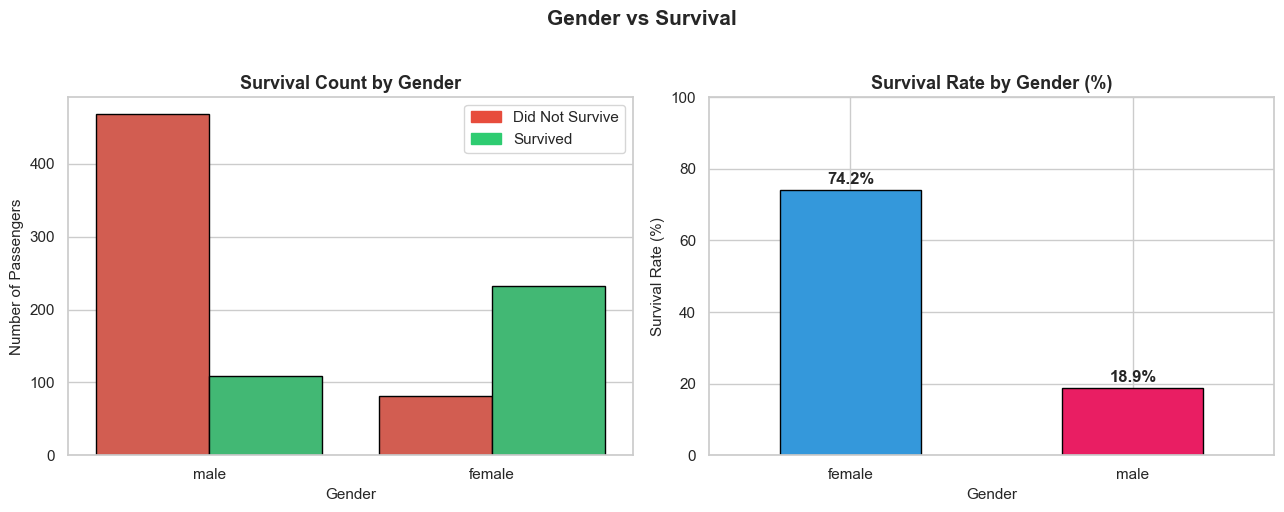

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Count plot
sns.countplot(data=df_clean, x='Sex', hue='Survived',
              palette={0: '#E74C3C', 1: '#2ECC71'},
              ax=axes[0], edgecolor='black')
axes[0].set_title('Survival Count by Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Number of Passengers', fontsize=11)
handles = [mpatches.Patch(color='#E74C3C', label='Did Not Survive'),
           mpatches.Patch(color='#2ECC71', label='Survived')]
axes[0].legend(handles=handles)

# Right: Survival rate by gender
survival_rate = df_clean.groupby('Sex')['Survived'].mean() * 100
survival_rate.plot(kind='bar', color=['#3498DB', '#E91E63'],
                   edgecolor='black', ax=axes[1], rot=0)
axes[1].set_title('Survival Rate by Gender (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=11)
axes[1].set_ylabel('Survival Rate (%)', fontsize=11)
axes[1].set_ylim(0, 100)
for i, v in enumerate(survival_rate):
    axes[1].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Gender vs Survival', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02_survival_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Survival by Passenger Class

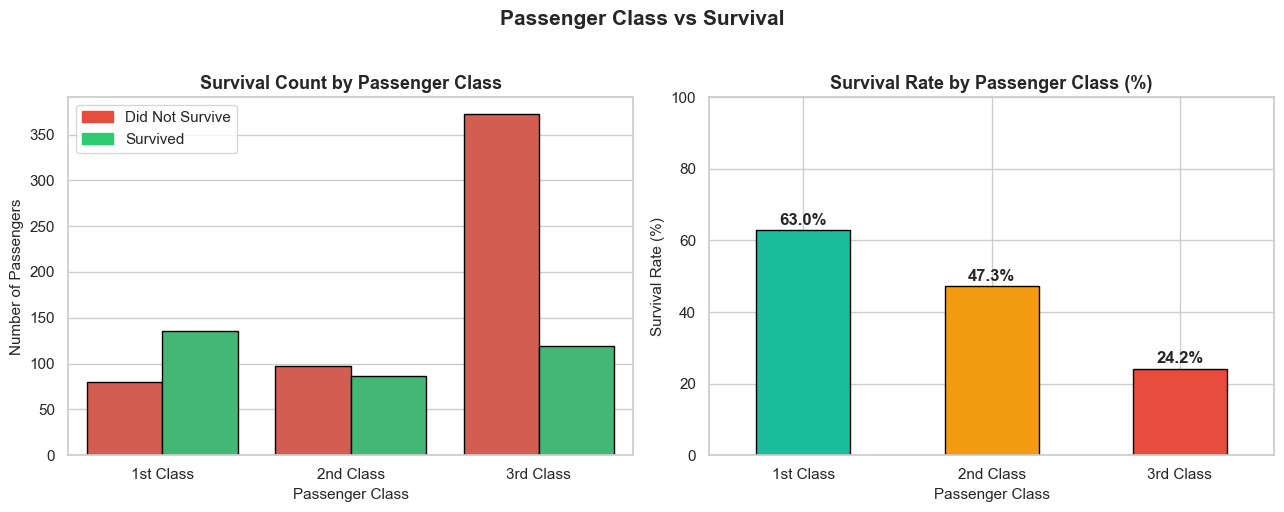

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Count plot
sns.countplot(data=df_clean, x='Pclass', hue='Survived',
              palette={0: '#E74C3C', 1: '#2ECC71'},
              ax=axes[0], edgecolor='black')
axes[0].set_title('Survival Count by Passenger Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Passenger Class', fontsize=11)
axes[0].set_ylabel('Number of Passengers', fontsize=11)
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
handles = [mpatches.Patch(color='#E74C3C', label='Did Not Survive'),
           mpatches.Patch(color='#2ECC71', label='Survived')]
axes[0].legend(handles=handles)

# Right: Survival rate by class
class_survival = df_clean.groupby('Pclass')['Survived'].mean() * 100
class_survival.plot(kind='bar', color=['#1ABC9C', '#F39C12', '#E74C3C'],
                    edgecolor='black', ax=axes[1], rot=0)
axes[1].set_title('Survival Rate by Passenger Class (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Passenger Class', fontsize=11)
axes[1].set_ylabel('Survival Rate (%)', fontsize=11)
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
axes[1].set_ylim(0, 100)
for i, v in enumerate(class_survival):
    axes[1].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Passenger Class vs Survival', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/03_survival_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Age Distribution

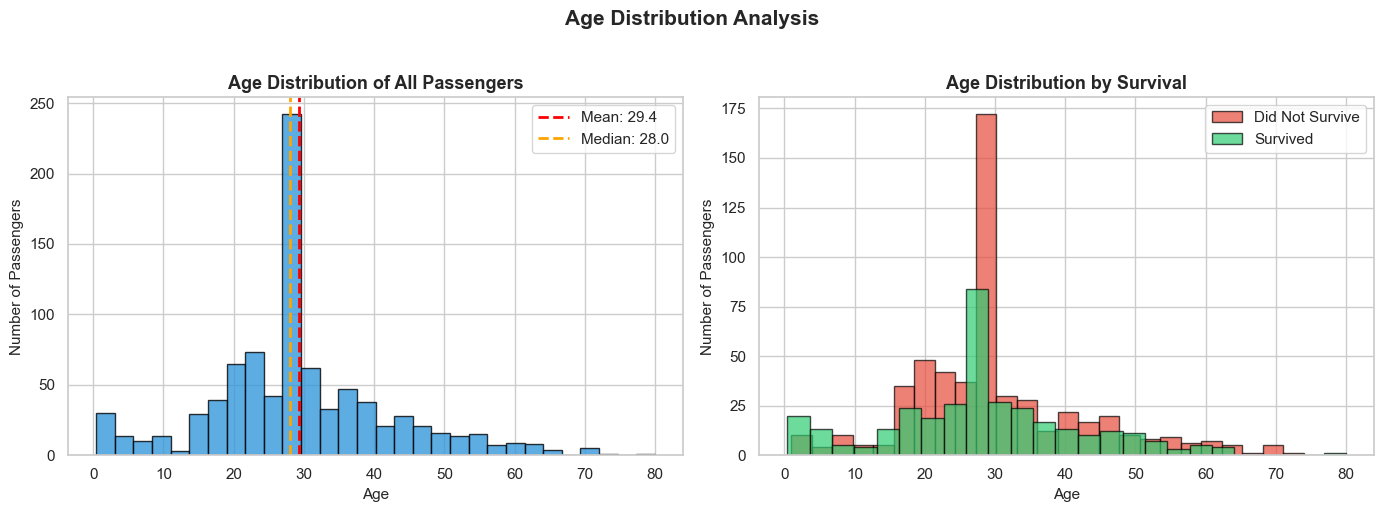

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Overall age distribution
axes[0].hist(df_clean['Age'], bins=30, color='#3498DB', edgecolor='black', alpha=0.8)
axes[0].axvline(df_clean['Age'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {df_clean["Age"].mean():.1f}')
axes[0].axvline(df_clean['Age'].median(), color='orange', linestyle='--',
                linewidth=2, label=f'Median: {df_clean["Age"].median():.1f}')
axes[0].set_title('Age Distribution of All Passengers', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Number of Passengers', fontsize=11)
axes[0].legend(fontsize=11)

# Right: Age distribution by survival
survived     = df_clean[df_clean['Survived'] == 1]['Age']
not_survived = df_clean[df_clean['Survived'] == 0]['Age']

axes[1].hist(not_survived, bins=25, alpha=0.7, color='#E74C3C',
             edgecolor='black', label='Did Not Survive')
axes[1].hist(survived, bins=25, alpha=0.7, color='#2ECC71',
             edgecolor='black', label='Survived')
axes[1].set_title('Age Distribution by Survival', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age', fontsize=11)
axes[1].set_ylabel('Number of Passengers', fontsize=11)
axes[1].legend(fontsize=11)

plt.suptitle('Age Distribution Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/04_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Fare Distribution

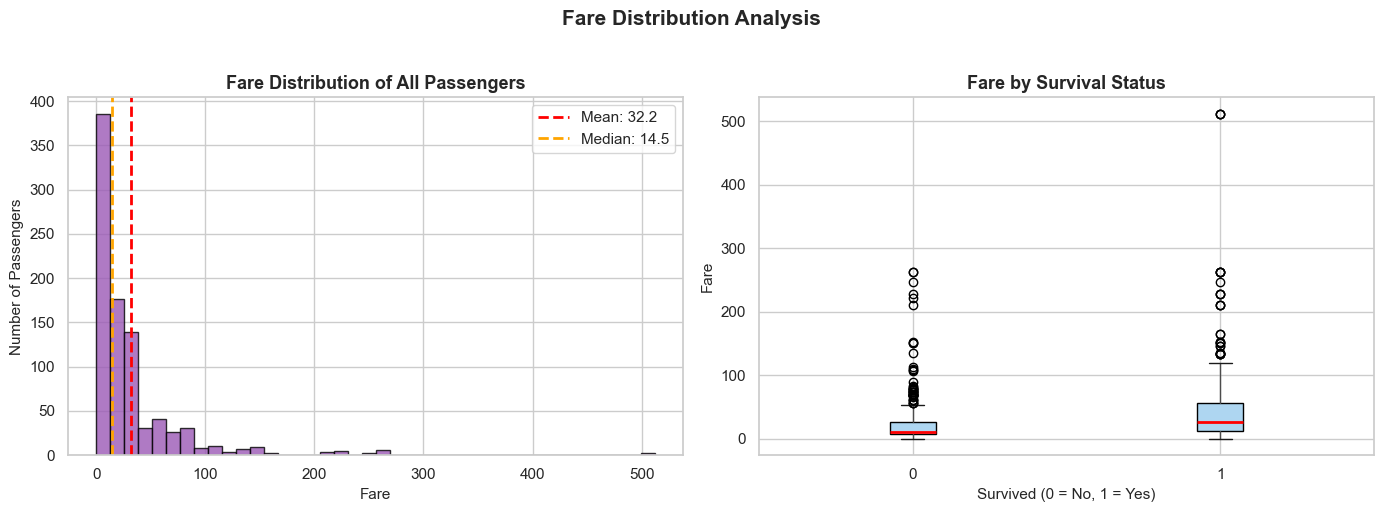

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Overall fare distribution
axes[0].hist(df_clean['Fare'], bins=40, color='#9B59B6', edgecolor='black', alpha=0.8)
axes[0].axvline(df_clean['Fare'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {df_clean["Fare"].mean():.1f}')
axes[0].axvline(df_clean['Fare'].median(), color='orange', linestyle='--',
                linewidth=2, label=f'Median: {df_clean["Fare"].median():.1f}')
axes[0].set_title('Fare Distribution of All Passengers', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fare', fontsize=11)
axes[0].set_ylabel('Number of Passengers', fontsize=11)
axes[0].legend(fontsize=11)

# Right: Fare by survival (box plot)
df_clean.boxplot(column='Fare', by='Survived', ax=axes[1],
                 patch_artist=True,
                 boxprops=dict(facecolor='#AED6F1'),
                 medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Fare by Survival Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Survived (0 = No, 1 = Yes)', fontsize=11)
axes[1].set_ylabel('Fare', fontsize=11)
plt.suptitle('')

plt.suptitle('Fare Distribution Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/05_fare_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 Correlation Heatmap

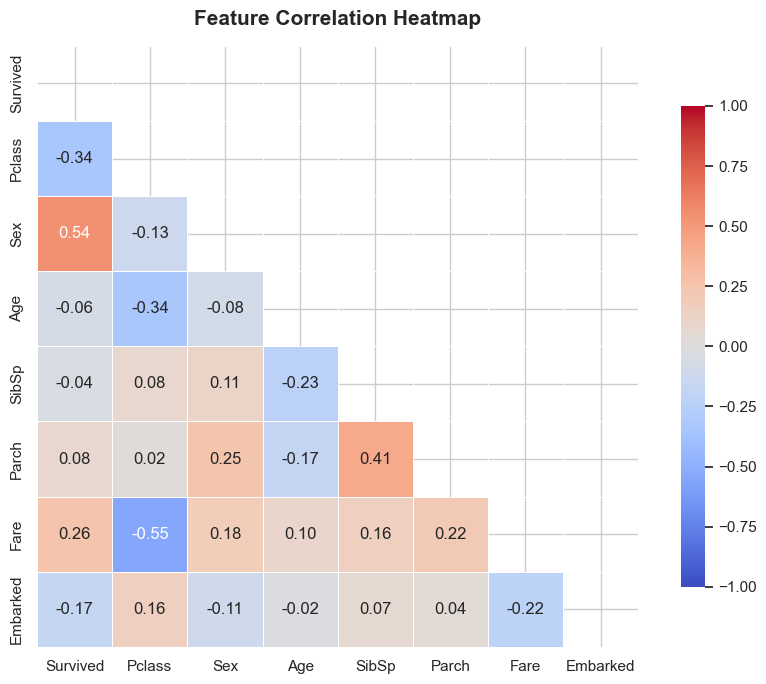

Key correlations with Survived:
Survived    1.000000
Sex         0.543351
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Embarked   -0.167675
Pclass     -0.338481


In [17]:
# Encode categorical columns for correlation calculation
df_corr = df_clean.copy()
df_corr['Sex'] = df_corr['Sex'].map({'male': 0, 'female': 1})
df_corr['Embarked'] = df_corr['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

plt.figure(figsize=(9, 7))
corr_matrix = df_corr.corr()

# Mask upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key correlations with Survived:')
print(corr_matrix['Survived'].sort_values(ascending=False).to_string())

---
## 8. Data Preprocessing

In [18]:
# Encode categorical variables
df_encoded = df_clean.copy()

# Sex: male -> 0, female -> 1
df_encoded['Sex'] = df_encoded['Sex'].map({'male': 0, 'female': 1})

# Embarked: C -> 0, Q -> 1, S -> 2
df_encoded['Embarked'] = df_encoded['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

print('Encoding complete.')
print('Sex     : male=0, female=1')
print('Embarked: C=0, Q=1, S=2')
print('\nData types after encoding:')
print(df_encoded.dtypes)

df_encoded.head()

Encoding complete.
Sex     : male=0, female=1
Embarked: C=0, Q=1, S=2

Data types after encoding:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,2
1,1,1,1,38.0,1,0,71.2833,0
2,1,3,1,26.0,0,0,7.9250,2
3,1,1,1,35.0,1,0,53.1000,2
4,0,3,0,35.0,0,0,8.0500,2


---
## 9. Feature Selection

In [19]:
# Define features (X) and target variable (y)
feature_columns = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target_column   = 'Survived'

X = df_encoded[feature_columns]   # Feature matrix
y = df_encoded[target_column]     # Target vector

print(f'Features (X) shape : {X.shape}')
print(f'Target (y) shape   : {y.shape}')
print(f'\nFeature columns: {feature_columns}')
print(f'Target column  : {target_column}')
print('\nTarget distribution:')
print(y.value_counts())

X.head()

Features (X) shape : (891, 7)
Target (y) shape   : (891,)

Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Target column  : Survived

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,2
1,1,1,38.0,1,0,71.2833,0
2,3,1,26.0,0,0,7.9250,2
3,1,1,35.0,1,0,53.1000,2
4,3,0,35.0,0,0,8.0500,2


---
## 10. Train-Test Split

In [20]:
# Split the data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Train-Test Split (80:20)')
print(f'Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing set    : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')

print('\nTraining target distribution:')
print(y_train.value_counts())
print('\nTesting target distribution:')
print(y_test.value_counts())

Train-Test Split (80:20)
Training set   : 712 samples (80%)
Testing set    : 179 samples (20%)

Training target distribution:
Survived
0    444
1    268
Name: count, dtype: int64

Testing target distribution:
Survived
0    105
1     74
Name: count, dtype: int64


---
## 11. Model Training

### 11.1 Logistic Regression

In [21]:
# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train, y_train)

print('Logistic Regression model trained successfully!')
print(f'Solver        : {lr_model.solver}')
print(f'Max iterations: {lr_model.max_iter}')

Logistic Regression model trained successfully!
Solver        : lbfgs
Max iterations: 200


### 11.2 Decision Tree

In [22]:
# Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

print('Decision Tree model trained successfully!')
print(f'Max depth             : {dt_model.max_depth}')
print(f'Number of features    : {dt_model.n_features_in_}')

Decision Tree model trained successfully!
Max depth             : 5
Number of features    : 7


---
## 12. Predictions

In [23]:
# Make predictions on the test set
lr_predictions = lr_model.predict(X_test)
dt_predictions = dt_model.predict(X_test)

# Preview first 10 predictions vs actual values
comparison = pd.DataFrame({
    'Actual'       : y_test.values[:10],
    'LR Prediction': lr_predictions[:10],
    'DT Prediction': dt_predictions[:10]
})
comparison['Actual Label'] = comparison['Actual'].map({0: 'Did Not Survive', 1: 'Survived'})
comparison['LR Predicted'] = comparison['LR Prediction'].map({0: 'Did Not Survive', 1: 'Survived'})
comparison['DT Predicted'] = comparison['DT Prediction'].map({0: 'Did Not Survive', 1: 'Survived'})

print('First 10 predictions vs Actual:')
comparison[['Actual Label', 'LR Predicted', 'DT Predicted']]

First 10 predictions vs Actual:


,Actual Label,LR Predicted,DT Predicted
0,Survived,Did Not Survive,Did Not Survive
1,Did Not Survive,Did Not Survive,Did Not Survive
2,Did Not Survive,Did Not Survive,Did Not Survive
3,Survived,Survived,Survived
4,Survived,Survived,Survived
5,Survived,Survived,Survived
6,Survived,Survived,Survived
7,Did Not Survive,Did Not Survive,Did Not Survive
8,Survived,Survived,Survived
9,Survived,Survived,Survived


---
## 13. Model Evaluation

### 13.1 Logistic Regression Evaluation

In [24]:
# Calculate Logistic Regression metrics
lr_accuracy  = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions, zero_division=0)
lr_recall    = recall_score(y_test, lr_predictions, zero_division=0)
lr_f1        = f1_score(y_test, lr_predictions, zero_division=0)

print('=' * 50)
print('  LOGISTIC REGRESSION - EVALUATION RESULTS')
print('=' * 50)
print(f'  Accuracy  : {lr_accuracy:.4f}  ({lr_accuracy * 100:.2f}%)')
print(f'  Precision : {lr_precision:.4f}')
print(f'  Recall    : {lr_recall:.4f}')
print(f'  F1-Score  : {lr_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lr_predictions,
                             target_names=['Did Not Survive', 'Survived']))

  LOGISTIC REGRESSION - EVALUATION RESULTS
  Accuracy  : 0.8101  (81.01%)
  Precision : 0.7857
  Recall    : 0.7432
  F1-Score  : 0.7639

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       105
       Survived       0.79      0.74      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



### 13.2 Decision Tree Evaluation

In [25]:
# Calculate Decision Tree metrics
dt_accuracy  = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(y_test, dt_predictions, zero_division=0)
dt_recall    = recall_score(y_test, dt_predictions, zero_division=0)
dt_f1        = f1_score(y_test, dt_predictions, zero_division=0)

print('=' * 50)
print('  DECISION TREE - EVALUATION RESULTS')
print('=' * 50)
print(f'  Accuracy  : {dt_accuracy:.4f}  ({dt_accuracy * 100:.2f}%)')
print(f'  Precision : {dt_precision:.4f}')
print(f'  Recall    : {dt_recall:.4f}')
print(f'  F1-Score  : {dt_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, dt_predictions,
                             target_names=['Did Not Survive', 'Survived']))

  DECISION TREE - EVALUATION RESULTS
  Accuracy  : 0.7989  (79.89%)
  Precision : 0.8276
  Recall    : 0.6486
  F1-Score  : 0.7273

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.79      0.90      0.84       105
       Survived       0.83      0.65      0.73        74

       accuracy                           0.80       179
      macro avg       0.81      0.78      0.78       179
   weighted avg       0.80      0.80      0.79       179



---
## 14. Confusion Matrix

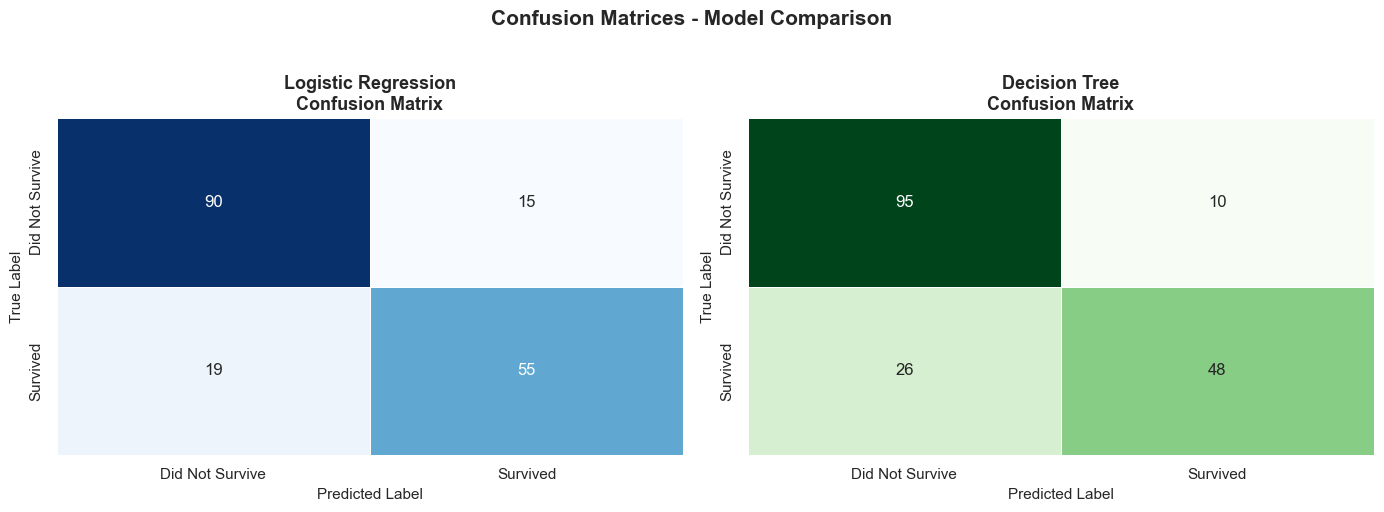

Confusion Matrix Legend:
  TN (top-left)     : True Negatives  - Correctly predicted Did Not Survive
  FP (top-right)    : False Positives - Incorrectly predicted Survived
  FN (bottom-left)  : False Negatives - Incorrectly predicted Did Not Survive
  TP (bottom-right) : True Positives  - Correctly predicted Survived


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_labels = ['Did Not Survive', 'Survived']

# Logistic Regression Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_predictions)
sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    ax=axes[0],
    cbar=False
)
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Decision Tree Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_predictions)
sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    ax=axes[1],
    cbar=False
)
axes[1].set_title('Decision Tree\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices - Model Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/07_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('Confusion Matrix Legend:')
print('  TN (top-left)     : True Negatives  - Correctly predicted Did Not Survive')
print('  FP (top-right)    : False Positives - Incorrectly predicted Survived')
print('  FN (bottom-left)  : False Negatives - Incorrectly predicted Did Not Survive')
print('  TP (bottom-right) : True Positives  - Correctly predicted Survived')

---
## 15. Model Comparison

In [27]:
# Side-by-side comparison table
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [
        round(lr_accuracy,  4),
        round(lr_precision, 4),
        round(lr_recall,    4),
        round(lr_f1,        4)
    ],
    'Decision Tree': [
        round(dt_accuracy,  4),
        round(dt_precision, 4),
        round(dt_recall,    4),
        round(dt_f1,        4)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df.set_index('Metric', inplace=True)

print('=' * 55)
print('         MODEL COMPARISON SUMMARY')
print('=' * 55)
print(comparison_df.to_string())
print('=' * 55)

if lr_accuracy >= dt_accuracy:
    print('\nWinner: Logistic Regression (equal or higher accuracy)')
else:
    print('\nWinner: Decision Tree (higher accuracy)')

         MODEL COMPARISON SUMMARY
           Logistic Regression  Decision Tree
Metric                                       
Accuracy                0.8101         0.7989
Precision               0.7857         0.8276
Recall                  0.7432         0.6486
F1-Score                0.7639         0.7273

Winner: Logistic Regression (equal or higher accuracy)


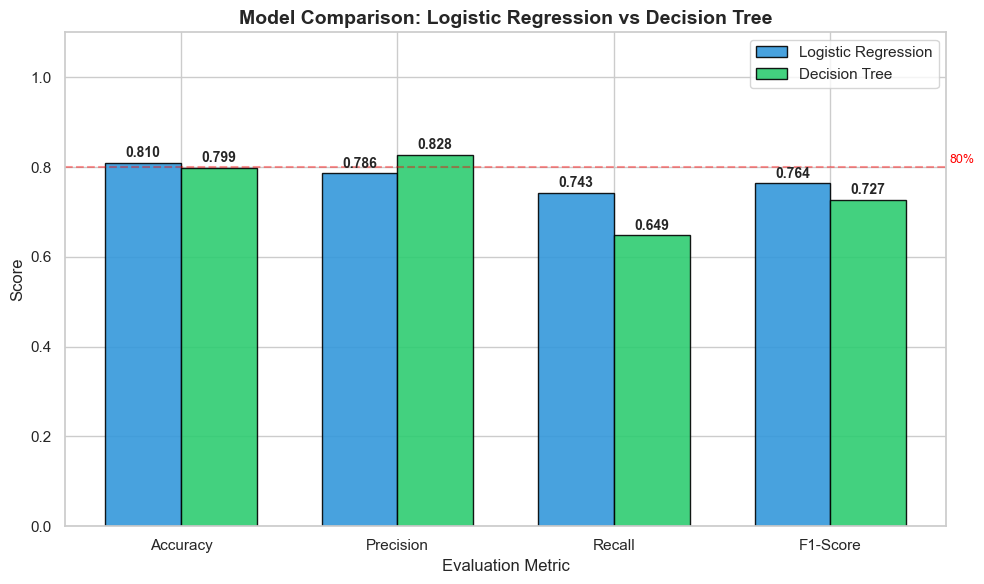

In [28]:
# Visual bar chart comparison
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [lr_accuracy, lr_precision, lr_recall, lr_f1]
dt_scores = [dt_accuracy, dt_precision, dt_recall, dt_f1]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression',
               color='#3498DB', edgecolor='black', alpha=0.9)
bars2 = ax.bar(x + width/2, dt_scores, width, label='Decision Tree',
               color='#2ECC71', edgecolor='black', alpha=0.9)

# Add value labels on each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Evaluation Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Logistic Regression vs Decision Tree',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.4, linewidth=1.5)
ax.text(3.55, 0.81, '80%', color='red', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 16. Sample Passenger Prediction

Enter any passenger details and get a prediction of whether they would have survived.

In [29]:
def predict_passenger(model, model_name, pclass, sex, age, sibsp, parch, fare, embarked):
    """
    Predict survival for a single passenger.

    Parameters
    ----------
    pclass   : int   (1, 2, or 3)
    sex      : str   ('male' or 'female')
    age      : float
    sibsp    : int
    parch    : int
    fare     : float
    embarked : str   ('C', 'Q', or 'S')
    """
    sex_enc      = 0 if sex.lower() == 'male' else 1
    embarked_enc = {'C': 0, 'Q': 1, 'S': 2}.get(embarked.upper(), 2)

    features   = np.array([[pclass, sex_enc, age, sibsp, parch, fare, embarked_enc]])
    prediction = model.predict(features)[0]

    try:
        prob = model.predict_proba(features)[0][prediction]
    except Exception:
        prob = None

    result = 'SURVIVED' if prediction == 1 else 'DID NOT SURVIVE'

    print(f'\n{"-" * 48}')
    print(f'  Model: {model_name}')
    print(f'  Passenger Details:')
    print(f'    Class    : {pclass}')
    print(f'    Sex      : {sex.capitalize()}')
    print(f'    Age      : {age} years')
    print(f'    SibSp    : {sibsp}')
    print(f'    Parch    : {parch}')
    print(f'    Fare     : {fare:.2f}')
    print(f'    Embarked : {embarked.upper()}')
    print(f'  {"─" * 40}')
    print(f'  Prediction : >>> {result} <<<')
    if prob is not None:
        print(f'  Confidence : {prob * 100:.1f}%')
    print(f'{"-" * 48}')

    return prediction


print('Prediction function defined. Running examples below.')

Prediction function defined. Running examples below.


In [30]:
# Example 1: 1st class female passenger (likely survived)
print('=' * 50)
print('EXAMPLE 1 - 1st Class Female Passenger')
print('=' * 50)

predict_passenger(lr_model, 'Logistic Regression',
                  pclass=1, sex='female', age=28,
                  sibsp=0, parch=0, fare=75.0, embarked='C')

predict_passenger(dt_model, 'Decision Tree',
                  pclass=1, sex='female', age=28,
                  sibsp=0, parch=0, fare=75.0, embarked='C')

EXAMPLE 1 - 1st Class Female Passenger

------------------------------------------------
  Model: Logistic Regression
  Passenger Details:
    Class    : 1
    Sex      : Female
    Age      : 28 years
    SibSp    : 0
    Parch    : 0
    Fare     : 75.00
    Embarked : C
  ────────────────────────────────────────
  Prediction : >>> SURVIVED <<<
  Confidence : 95.1%
------------------------------------------------

------------------------------------------------
  Model: Decision Tree
  Passenger Details:
    Class    : 1
    Sex      : Female
    Age      : 28 years
    SibSp    : 0
    Parch    : 0
    Fare     : 75.00
    Embarked : C
  ────────────────────────────────────────
  Prediction : >>> SURVIVED <<<
  Confidence : 100.0%
------------------------------------------------


1

In [31]:
# Example 2: 3rd class male passenger (likely did not survive)
print('=' * 50)
print('EXAMPLE 2 - 3rd Class Male Passenger')
print('=' * 50)

predict_passenger(lr_model, 'Logistic Regression',
                  pclass=3, sex='male', age=22,
                  sibsp=1, parch=0, fare=7.25, embarked='S')

predict_passenger(dt_model, 'Decision Tree',
                  pclass=3, sex='male', age=22,
                  sibsp=1, parch=0, fare=7.25, embarked='S')

EXAMPLE 2 - 3rd Class Male Passenger

------------------------------------------------
  Model: Logistic Regression
  Passenger Details:
    Class    : 3
    Sex      : Male
    Age      : 22 years
    SibSp    : 1
    Parch    : 0
    Fare     : 7.25
    Embarked : S
  ────────────────────────────────────────
  Prediction : >>> DID NOT SURVIVE <<<
  Confidence : 90.2%
------------------------------------------------

------------------------------------------------
  Model: Decision Tree
  Passenger Details:
    Class    : 3
    Sex      : Male
    Age      : 22 years
    SibSp    : 1
    Parch    : 0
    Fare     : 7.25
    Embarked : S
  ────────────────────────────────────────
  Prediction : >>> DID NOT SURVIVE <<<
  Confidence : 86.9%
------------------------------------------------


0

In [32]:
# Example 3: 2nd class elderly male passenger
print('=' * 50)
print('EXAMPLE 3 - 2nd Class Elderly Male Passenger')
print('=' * 50)

predict_passenger(lr_model, 'Logistic Regression',
                  pclass=2, sex='male', age=60,
                  sibsp=0, parch=1, fare=26.0, embarked='Q')

predict_passenger(dt_model, 'Decision Tree',
                  pclass=2, sex='male', age=60,
                  sibsp=0, parch=1, fare=26.0, embarked='Q')

EXAMPLE 3 - 2nd Class Elderly Male Passenger

------------------------------------------------
  Model: Logistic Regression
  Passenger Details:
    Class    : 2
    Sex      : Male
    Age      : 60 years
    SibSp    : 0
    Parch    : 1
    Fare     : 26.00
    Embarked : Q
  ────────────────────────────────────────
  Prediction : >>> DID NOT SURVIVE <<<
  Confidence : 88.0%
------------------------------------------------

------------------------------------------------
  Model: Decision Tree
  Passenger Details:
    Class    : 2
    Sex      : Male
    Age      : 60 years
    SibSp    : 0
    Parch    : 1
    Fare     : 26.00
    Embarked : Q
  ────────────────────────────────────────
  Prediction : >>> DID NOT SURVIVE <<<
  Confidence : 94.4%
------------------------------------------------


0

In [33]:
# --------------------------------------------------
# TRY YOUR OWN PASSENGER - Edit the values below!
# --------------------------------------------------
print('TRY YOUR OWN PASSENGER:')
print('Edit the values and re-run this cell.\n')

MY_PCLASS   = 2         # 1, 2, or 3
MY_SEX      = 'female'  # 'male' or 'female'
MY_AGE      = 35.0      # Age in years
MY_SIBSP    = 1         # Siblings/spouses aboard
MY_PARCH    = 0         # Parents/children aboard
MY_FARE     = 30.0      # Ticket fare
MY_EMBARKED = 'S'       # 'C', 'Q', or 'S'

predict_passenger(lr_model, 'Logistic Regression',
                  pclass=MY_PCLASS, sex=MY_SEX, age=MY_AGE,
                  sibsp=MY_SIBSP, parch=MY_PARCH,
                  fare=MY_FARE, embarked=MY_EMBARKED)

TRY YOUR OWN PASSENGER:
Edit the values and re-run this cell.


------------------------------------------------
  Model: Logistic Regression
  Passenger Details:
    Class    : 2
    Sex      : Female
    Age      : 35.0 years
    SibSp    : 1
    Parch    : 0
    Fare     : 30.00
    Embarked : S
  ────────────────────────────────────────
  Prediction : >>> SURVIVED <<<
  Confidence : 72.6%
------------------------------------------------


1

---
## 17. Results Summary

In [34]:
print('=' * 60)
print('            FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'Dataset          : Kaggle Titanic (train.csv)')
print(f'Total Samples    : {len(df)}')
print(f'Training Samples : {len(X_train)}')
print(f'Testing Samples  : {len(X_test)}')
print(f'Features Used    : Pclass, Sex, Age, SibSp, Parch, Fare, Embarked')
print()
print(f'{"Metric":<15} {"Logistic Regression":>22} {"Decision Tree":>15}')
print(f'{"─" * 55}')
print(f'{"Accuracy":<15} {lr_accuracy:>22.4f} {dt_accuracy:>15.4f}')
print(f'{"Precision":<15} {lr_precision:>22.4f} {dt_precision:>15.4f}')
print(f'{"Recall":<15} {lr_recall:>22.4f} {dt_recall:>15.4f}')
print(f'{"F1-Score":<15} {lr_f1:>22.4f} {dt_f1:>15.4f}')
print(f'{"─" * 55}')

best     = 'Logistic Regression' if lr_accuracy >= dt_accuracy else 'Decision Tree'
best_acc = max(lr_accuracy, dt_accuracy)
print(f'\nBest Model  : {best}')
print(f'Accuracy    : {best_acc * 100:.2f}%')
print('=' * 60)

            FINAL RESULTS SUMMARY
Dataset          : Kaggle Titanic (train.csv)
Total Samples    : 891
Training Samples : 712
Testing Samples  : 179
Features Used    : Pclass, Sex, Age, SibSp, Parch, Fare, Embarked

Metric             Logistic Regression   Decision Tree
───────────────────────────────────────────────────────
Accuracy                        0.8101          0.7989
Precision                       0.7857          0.8276
Recall                          0.7432          0.6486
F1-Score                        0.7639          0.7273
───────────────────────────────────────────────────────

Best Model  : Logistic Regression
Accuracy    : 81.01%


---
## 18. Conclusion

### Key Findings from EDA

1. **Gender** was the strongest predictor. Females had a significantly higher survival rate (~74%) compared to males (~19%), reflecting the "women and children first" evacuation policy.
2. **Passenger Class** mattered greatly. 1st class passengers had the highest survival rate (~63%), while 3rd class had the lowest (~24%).
3. **Age** showed that children had slightly better survival rates.
4. **Fare** was positively correlated with survival. Passengers who paid higher fares (typically 1st class) survived more often.

### Model Performance

- Both **Logistic Regression** and **Decision Tree** achieved reasonable accuracy (~78-82%) on the Titanic dataset.
- Logistic Regression is a simple, fast, and interpretable baseline model.
- Decision Tree provides a visually interpretable model but can overfit without depth constraints.

### What We Learned

- Data cleaning and handling missing values is crucial before model training.
- Exploratory Data Analysis reveals important patterns that guide feature selection.
- Model evaluation should go beyond accuracy. Precision, recall, and F1-score provide a more complete picture.
- The Titanic dataset demonstrates how socioeconomic factors (class, fare) and demographics (gender, age) influenced survival chances.

---

*This project was built as a college mini-project to demonstrate fundamental Machine Learning concepts.*